# 03 — SHAP Explanations

Computes **TreeSHAP attributions** for every replica of every window pair, restricted to the flagged instances $F_{A,B}$.

**Input:** `data/models/pair_{i:02d}/` (from notebook 02)  
**Output per pair:** under `data/shap/pair_{i:02d}/`
- `shap_A.npy` — shape `(R, |F_{A,B}|, p)` (replicas × flagged instances × features)
- `shap_B.npy` — shape `(R, |F_{A,B}|, p)`
- `expected_values_A.npy` — shape `(R,)`, dtype float32
- `expected_values_B.npy` — shape `(R,)`, dtype float32
- `stochasticity.json` — `{"best_replica_A": int, "max_abs_diff": float, "is_deterministic": bool}`




In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pip install -q shap joblib pyarrow xgboost

In [3]:
import json
import joblib
import numpy as np
import pandas as pd
import shap
from pathlib import Path

WORKSPACE = Path('/content/drive/MyDrive/Home Insurance XGBoost')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'
MODEL_DIR = WORKSPACE / 'data' / 'models'
SHAP_DIR  = WORKSPACE / 'data' / 'shap'
SHAP_DIR.mkdir(parents=True, exist_ok=True)

print(f'SHAP version: {shap.__version__}')


SHAP version: 0.51.0


In [4]:
X = pd.read_parquet(PROC_DIR / 'X.parquet').values.astype(np.float32)

with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)
feature_names = feature_names_json['all']

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R = config['parameters']['R']
PAIR_STRIDE = config['parameters'].get('PAIR_STRIDE', 1)
TIME_UNIT = config['parameters'].get('time_unit', 'step')
pairs = config['pairs']

print(f'X: {X.shape}, features: {len(feature_names)}')
print(f'R={R}, PAIR_STRIDE={PAIR_STRIDE}, time_unit={TIME_UNIT}, pairs={len(pairs)}')


X: (260753, 317), features: 317
R=5, PAIR_STRIDE=4, time_unit=month, pairs=5


## SHAP computation loop

For each pair and each replica:
1. Load the model from notebook 02.
2. Recover the flagged instances using `predictions.npz`.
3. Compute TreeSHAP values on the raw flagged feature matrix.
4. Save replica-level SHAP tensors and expected values immediately.


In [5]:
for p in pairs:
    pid = p['pair_id']
    pair_dir = MODEL_DIR / f'pair_{pid:02d}'
    shap_dir = SHAP_DIR / f'pair_{pid:02d}'

    shap_A_path = shap_dir / 'shap_A.npy'
    shap_B_path = shap_dir / 'shap_B.npy'

    if shap_A_path.exists() and shap_B_path.exists():
        print(f'Pair {pid:02d}: SHAP already computed, skipping.')
        continue

    print(
        f'\n── Pair {pid:02d}: '
        f'A_end={p["step_label_A"]}  '
        f'B_end={p["step_label_B"]}  '
        f'eval={p["eval_start_label"]}→{p["eval_end_label"]}  '
        f'PAIR_STRIDE={PAIR_STRIDE} ──'
    )

    shap_dir.mkdir(parents=True, exist_ok=True)

    pred_data = np.load(pair_dir / 'predictions.npz')
    flagged_local_idx = pred_data['flagged_idx']
    idx_eval = np.array(p['idx_eval'], dtype=np.int64)

    flagged_global_idx = idx_eval[flagged_local_idx]
    X_flagged = X[flagged_global_idx]

    n_flagged = X_flagged.shape[0]
    n_feat = X_flagged.shape[1]
    print(f'  Flagged instances: {n_flagged:,}  Features: {n_feat}')

    if n_flagged == 0:
        print('  WARNING: no flagged instances — skipping.')
        continue

    shap_A = np.zeros((R, n_flagged, n_feat), dtype=np.float32)
    ev_A = np.zeros(R, dtype=np.float32)
    for r in range(R):
        model = joblib.load(pair_dir / 'replicas_A' / f'model_r{r}.joblib')
        explainer = shap.TreeExplainer(model)
        vals = explainer.shap_values(X_flagged)
        if isinstance(vals, list):
            vals = vals[1]
        shap_A[r] = vals.astype(np.float32)
        raw_ev = explainer.expected_value
        ev_A[r] = np.float32(raw_ev if not isinstance(raw_ev, list) else raw_ev[1])
        print(f'  A replica {r}: SHAP computed  |mean|={np.abs(shap_A[r]).mean():.5f}  base={ev_A[r]:.4f}')

    shap_B = np.zeros((R, n_flagged, n_feat), dtype=np.float32)
    ev_B = np.zeros(R, dtype=np.float32)
    for r in range(R):
        model = joblib.load(pair_dir / 'replicas_B' / f'model_r{r}.joblib')
        explainer = shap.TreeExplainer(model)
        vals = explainer.shap_values(X_flagged)
        if isinstance(vals, list):
            vals = vals[1]
        shap_B[r] = vals.astype(np.float32)
        raw_ev = explainer.expected_value
        ev_B[r] = np.float32(raw_ev if not isinstance(raw_ev, list) else raw_ev[1])
        print(f'  B replica {r}: SHAP computed  |mean|={np.abs(shap_B[r]).mean():.5f}  base={ev_B[r]:.4f}')

    model_A0 = joblib.load(pair_dir / 'replicas_A' / 'model_r0.joblib')
    logit_pred_A0 = model_A0.predict(X_flagged, output_margin=True)
    recon_A0 = ev_A[0] + shap_A[0].sum(axis=1)
    max_abs_err = float(np.max(np.abs(logit_pred_A0 - recon_A0)))
    print(f'  Sanity check A replica 0: max |margin - (base + sum SHAP)| = {max_abs_err:.3e}')

    np.save(shap_A_path, shap_A)
    np.save(shap_B_path, shap_B)
    np.save(shap_dir / 'expected_values_A.npy', ev_A)
    np.save(shap_dir / 'expected_values_B.npy', ev_B)

    summary = {
        'pair_id': int(pid),
        'n_flagged': int(n_flagged),
        'n_features': int(n_feat),
        'pair_stride': int(PAIR_STRIDE),
        'time_unit': TIME_UNIT,
        'sanity_check_max_abs_err_A_r0': max_abs_err,
    }
    with open(shap_dir / 'summary.json', 'w') as f:
        json.dump(summary, f, indent=2)

    print(f'  Saved SHAP outputs to {shap_dir}')

print('\n✓ SHAP computation complete.')


Pair 00: SHAP already computed, skipping.
Pair 01: SHAP already computed, skipping.
Pair 02: SHAP already computed, skipping.
Pair 03: SHAP already computed, skipping.
Pair 04: SHAP already computed, skipping.

✓ SHAP computation complete.


## SHAP stochasticity diagnostic

TreeSHAP is deterministic for a fixed model. This notebook verifies that claim for every pair using the best-performing A replica, exactly as in the example notebook.


In [6]:
for p in pairs:
    pid = p['pair_id']
    pair_dir = MODEL_DIR / f'pair_{pid:02d}'
    shap_dir = SHAP_DIR / f'pair_{pid:02d}'
    shap_dir.mkdir(parents=True, exist_ok=True)

    print(f'\n── Pair {pid:02d} stochasticity diagnostic ──')

    pred_data = np.load(pair_dir / 'predictions.npz')
    idx_eval = np.array(p['idx_eval'], dtype=np.int64)
    flagged_local_idx = pred_data['flagged_idx']
    flagged_global_idx = idx_eval[flagged_local_idx]
    X_flagged = X[flagged_global_idx]

    per_auc_A = pred_data['per_replica_pr_auc_A']
    best_r = int(np.argmax(per_auc_A))
    print(f'  Best replica of A: r={best_r}  (PR-AUC={per_auc_A[best_r]:.4f})')

    model_best = joblib.load(pair_dir / 'replicas_A' / f'model_r{best_r}.joblib')
    exp = shap.TreeExplainer(model_best)

    run1 = exp.shap_values(X_flagged)
    if isinstance(run1, list):
        run1 = run1[1]
    run2 = exp.shap_values(X_flagged)
    if isinstance(run2, list):
        run2 = run2[1]

    max_abs_diff = float(np.abs(run1 - run2).max()) if X_flagged.shape[0] > 0 else 0.0
    is_det = max_abs_diff < 1e-6
    print(f'  Max |run1 - run2|: {max_abs_diff:.2e}')
    print('  TreeSHAP is deterministic ✓' if is_det else '  WARNING: non-zero stochasticity!')

    stoch = {
        'best_replica_A': best_r,
        'max_abs_diff': max_abs_diff,
        'is_deterministic': is_det,
    }
    with open(shap_dir / 'stochasticity.json', 'w') as f:
        json.dump(stoch, f, indent=2)
    print('  Saved stochasticity.json')

print('\n✓ Stochasticity diagnostic complete.')



── Pair 00 stochasticity diagnostic ──
  Best replica of A: r=4  (PR-AUC=0.8824)
  Max |run1 - run2|: 0.00e+00
  TreeSHAP is deterministic ✓
  Saved stochasticity.json

── Pair 01 stochasticity diagnostic ──
  Best replica of A: r=3  (PR-AUC=0.9002)
  Max |run1 - run2|: 0.00e+00
  TreeSHAP is deterministic ✓
  Saved stochasticity.json

── Pair 02 stochasticity diagnostic ──
  Best replica of A: r=0  (PR-AUC=0.8767)
  Max |run1 - run2|: 0.00e+00
  TreeSHAP is deterministic ✓
  Saved stochasticity.json

── Pair 03 stochasticity diagnostic ──
  Best replica of A: r=3  (PR-AUC=0.8425)
  Max |run1 - run2|: 0.00e+00
  TreeSHAP is deterministic ✓
  Saved stochasticity.json

── Pair 04 stochasticity diagnostic ──
  Best replica of A: r=1  (PR-AUC=0.8773)
  Max |run1 - run2|: 0.00e+00
  TreeSHAP is deterministic ✓
  Saved stochasticity.json

✓ Stochasticity diagnostic complete.


## Quick SHAP summary (pair 0)

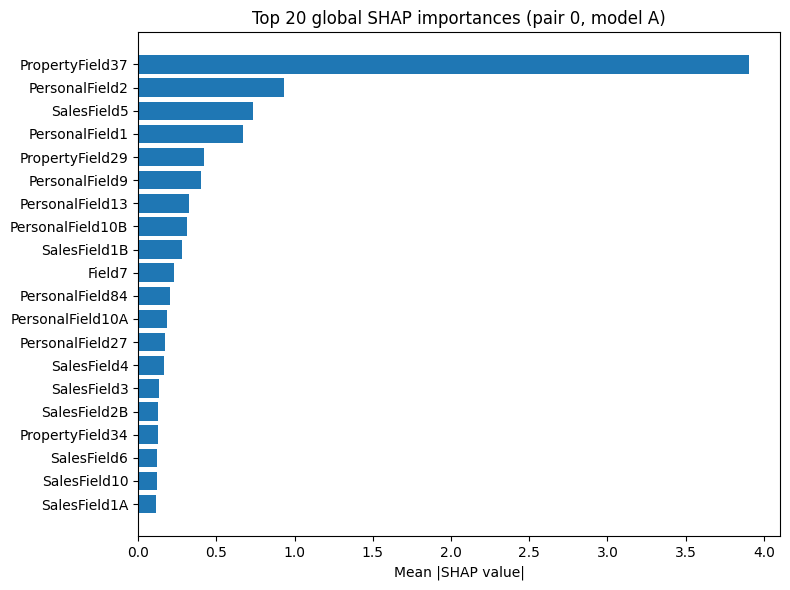

In [7]:
import matplotlib.pyplot as plt

shap_A_0 = np.load(SHAP_DIR / 'pair_00' / 'shap_A.npy')
phi_bar_A = shap_A_0.mean(axis=0)

global_imp = np.abs(phi_bar_A).mean(axis=0)
top_k = 20
top_idx = np.argsort(global_imp)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    [feature_names[i] for i in top_idx[::-1]],
    global_imp[top_idx[::-1]]
)
ax.set_title('Top 20 global SHAP importances (pair 0, model A)')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig(SHAP_DIR / 'global_importance_pair00_A.png', dpi=120)
plt.show()
